# Load data

In [1]:
import sys
sys.path.append('../Common')

import CommonYFinance

In [2]:
symbol = 'VCB.VN'
from_date = '2023-09-01'
to_date = '2024-06-28'
interval = '1d'
data = CommonYFinance.CommonYFinance.loaddataYFinance(symbol, from_date, to_date, interval)

[*********************100%%**********************]  1 of 1 completed


In [3]:
data

,Datetime,Open,High,Low,Close,Volume
0,2023-09-05,89100.0,90700.0,89100.0,90100.0,2013202
1,2023-09-06,90200.0,90200.0,89700.0,90200.0,2057603
2,2023-09-07,90000.0,90800.0,89500.0,89500.0,1958302
3,2023-09-08,89500.0,89500.0,89100.0,89500.0,1381905
4,2023-09-11,89600.0,90000.0,88000.0,88500.0,2592500
...,...,...,...,...,...,...
196,2024-06-21,86100.0,86700.0,85500.0,86000.0,1850476
197,2024-06-24,86000.0,87400.0,85500.0,85500.0,2189975
198,2024-06-25,85700.0,86700.0,85500.0,85500.0,1586014
199,2024-06-26,85900.0,86300.0,85200.0,85200.0,1727058


In [4]:
data.to_csv('data.csv')

In [5]:
symbol = 'EURUSD'
from_date = '2023-09-20'
to_date = '2023-11-30'

dataMT5 = CommonMT5.CommonMT5.loaddataMT5(symbol, from_date, to_date)

dataMT5

NameError: name 'CommonMT5' is not defined

In [ ]:
symbol = 'EUR/USDT'
from_date = '2023-09-20'
to_date = '2023-11-30'
timeframe = '15m'

dataBinance = CommonBinance.CommonBinance.loaddataBinance_FromTo(symbol, from_date, to_date, timeframe)

In [ ]:
dataBinance

,Datetime,Open,High,Low,Close,Volume
0,2023-09-20 00:00:00,1.0665,1.0665,1.0664,1.0664,16158.0
1,2023-09-20 00:15:00,1.0664,1.0665,1.0664,1.0664,12162.5
2,2023-09-20 00:30:00,1.0665,1.0665,1.0664,1.0664,12481.4
3,2023-09-20 00:45:00,1.0665,1.0666,1.0664,1.0666,34517.9
4,2023-09-20 01:00:00,1.0665,1.0666,1.0665,1.0665,9439.9
...,...,...,...,...,...,...
995,2023-09-30 08:45:00,1.0561,1.0561,1.0560,1.0561,74621.2
996,2023-09-30 09:00:00,1.0561,1.0561,1.0560,1.0561,145998.2
997,2023-09-30 09:15:00,1.0560,1.0561,1.0560,1.0561,107618.3
998,2023-09-30 09:30:00,1.0560,1.0561,1.0560,1.0561,157711.9


In [ ]:
symbol = 'EUR/USDT'
from_date = '2023-09-20'
to_date = '2023-11-30'

dataBinance = CommonBinance.CommonBinance.loaddataBinance_Limit(symbol, from_date, to_date)

In [ ]:
symbol = 'EUR/USDT'
from_date = '2023-09-20'
to_date = '2023-11-20'

dataBinance = CommonBinance.CommonBinance.loaddataBinance_FromToExt(symbol, from_date, to_date)

# Duong MACD va SMA + Chien luoc ML, MACD va SMA

In [ ]:
data

,Datetime,Open,High,Low,Close,Volume
0,2023-09-05,89100.0,90700.0,89100.0,90100.0,2013202
1,2023-09-06,90200.0,90200.0,89700.0,90200.0,2057603
2,2023-09-07,90000.0,90800.0,89500.0,89500.0,1958302
3,2023-09-08,89500.0,89500.0,89100.0,89500.0,1381905
4,2023-09-11,89600.0,90000.0,88000.0,88500.0,2592500
...,...,...,...,...,...,...
196,2024-06-21,86100.0,86700.0,85500.0,86000.0,1850476
197,2024-06-24,86000.0,87400.0,85500.0,85500.0,2189975
198,2024-06-25,85700.0,86700.0,85500.0,85500.0,1586014
199,2024-06-26,85900.0,86300.0,85200.0,85200.0,1727058


Mean Squared Error (MSE): 1032348.7339045268


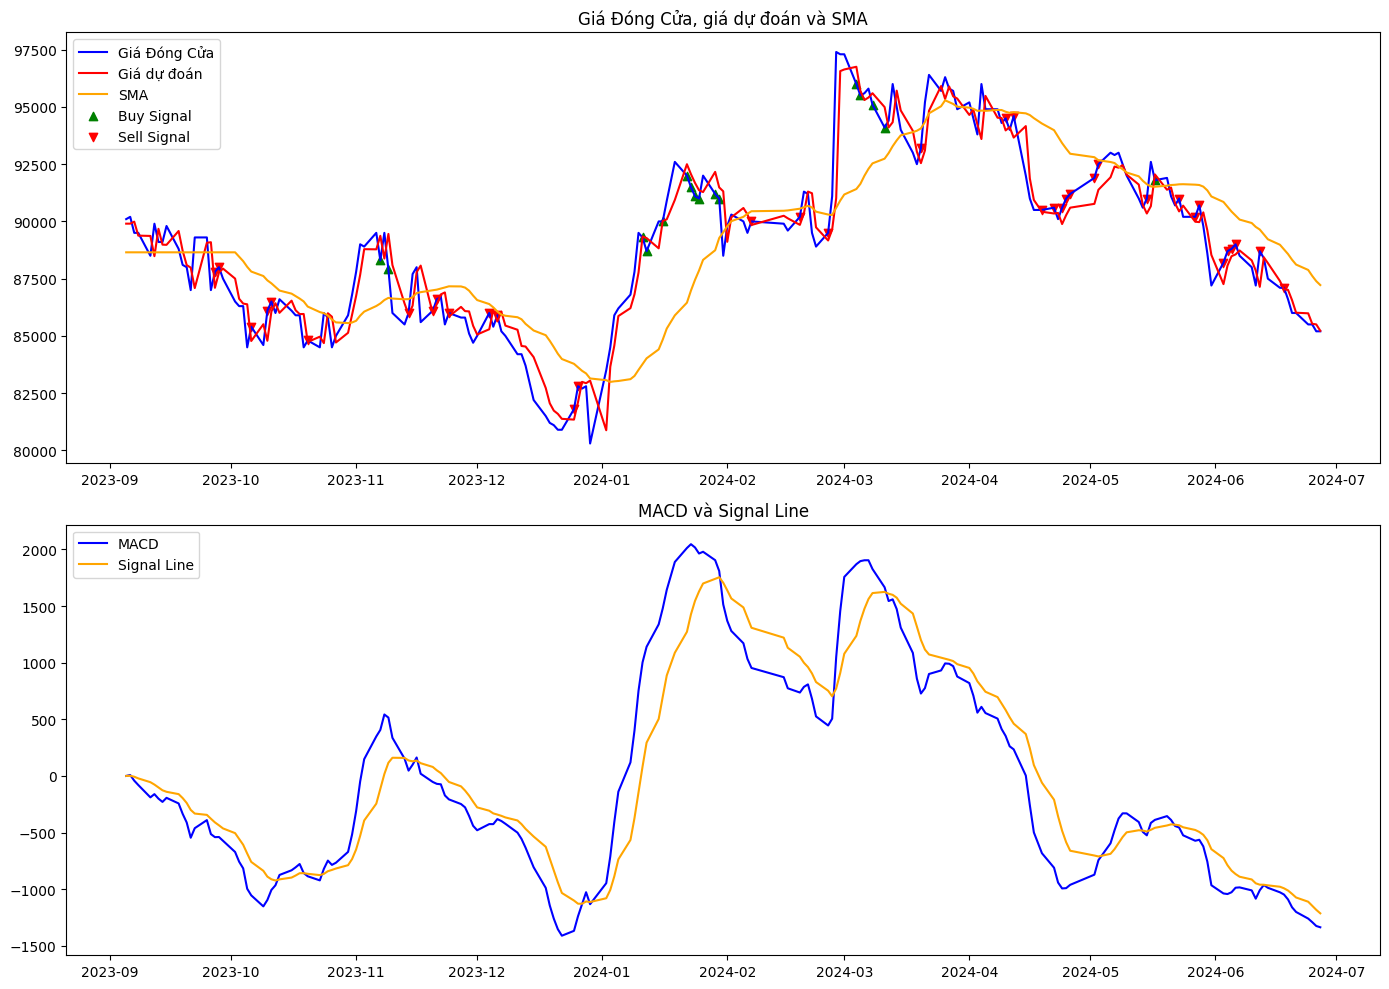

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Đọc dữ liệu từ file CSV
# data = pd.read_csv('path_to_file.csv')
# Giả sử DataFrame 'data' đã được tạo và chứa cột 'Datetime' và 'Close'
# Đoạn mã này giả định rằng 'data' đã sẵn có trong môi trường làm việc của bạn

# Thiết lập 'Datetime' làm chỉ mục của DataFrame
data['Datetime'] = pd.to_datetime(data['Datetime'])
data.set_index('Datetime', inplace=True)

# Thiết lập cửa sổ thời gian cho SMA và độ lệch chuẩn
window = 20

# Tính toán SMA cho giá đóng cửa
data['SMA'] = data['Close'].rolling(window=window).mean()

# Tính toán MACD
data['short_ema'] = data['Close'].ewm(span=12, adjust=False).mean()
data['long_ema'] = data['Close'].ewm(span=26, adjust=False).mean()
data['MACD'] = data['short_ema'] - data['long_ema']
data['Signal_Line'] = data['MACD'].ewm(span=9, adjust=False).mean()

########################################### ML
data['MACD'] = data['MACD'].bfill().ffill()
data['SMA'] = data['SMA'].bfill().ffill()

features = data[['Close', 'MACD', 'SMA']].shift(1)  # Use previous day's values to predict next day's close
target = data['Close'].shift(-1)  # Shift(-1) to predict next day's close

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=0)
X_train = X_train.bfill().ffill()
y_train = y_train.bfill().ffill()

# Initialize and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Đảm bảo không có giá trị NaN trong X trước khi dự đoán
X = features.bfill().ffill()

# Predict and evaluate the model
data['Predicted_Close'] = model.predict(X)

# Có thể sử dụng MSE để đánh giá mô hình ổn thì làm bước kế tiếp
# Tính Mean Squared Error (MSE) giữa giá trị thực tế và giá trị dự đoán trên tập kiểm tra
mse = mean_squared_error(data['Close'], data['Predicted_Close'])
print(f'Mean Squared Error (MSE): {mse}')

# Calculate Buy and Sell signals including predicted close price
data['Buy_Signal'] = (data['MACD'] > data['Signal_Line']) & (data['Predicted_Close'] > data['Close']) & (data['Close'] > data['SMA'])
data['Sell_Signal'] = (data['MACD'] < data['Signal_Line']) & (data['Predicted_Close'] < data['Close']) & (data['Close'] < data['SMA'])

# Vẽ biểu đồ
plt.figure(figsize=(14, 10))

# Biểu đồ giá đóng cửa và SMA
plt.subplot(211)
plt.plot(data.index, data['Close'], label='Giá Đóng Cửa', color='blue')
plt.plot(data.index, data['Predicted_Close'], label='Giá dự đoán', color='red')
plt.plot(data.index, data['SMA'], label='SMA', color='orange')
plt.scatter(data.index[data['Buy_Signal']], data['Close'][data['Buy_Signal']], label='Buy Signal', marker='^', color='green')
plt.scatter(data.index[data['Sell_Signal']], data['Close'][data['Sell_Signal']], label='Sell Signal', marker='v', color='red')
plt.legend(loc='upper left')
plt.title('Giá Đóng Cửa, giá dự đoán và SMA')

# Biểu đồ MACD
plt.subplot(212)
plt.plot(data.index, data['MACD'], label='MACD', color='blue')
plt.plot(data.index, data['Signal_Line'], label='Signal Line', color='orange')
plt.legend(loc='upper left')
plt.title('MACD và Signal Line')

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import plotly.graph_objects as go

# ... (Giữ phần import và tính toán MACD/SMA giống như bạn đã làm)

####################################################################################################
# Tạo figure
fig = go.Figure()

# Biểu đồ giá đóng cửa và SMA
fig.add_trace(go.Scatter(x=data.index, y=data['Close'], mode='lines', name='Giá Đóng Cửa', line=dict(color='blue')))
fig.add_trace(go.Scatter(x=data.index, y=data['Predicted_Close'], mode='lines', name='Giá dự đoán', line=dict(color='red')))
fig.add_trace(go.Scatter(x=data.index, y=data['SMA'], mode='lines', name='SMA', line=dict(color='orange')))

# Vẽ các điểm cho tín hiệu mua
buy_signals = data[data['Buy_Signal']]
fig.add_trace(go.Scatter(x=buy_signals.index, y=buy_signals['Close'], mode='markers', name='Buy Signal', marker=dict(symbol='triangle-up', size=10, color='green')))

# Vẽ các điểm cho tín hiệu bán
sell_signals = data[data['Sell_Signal']]
fig.add_trace(go.Scatter(x=sell_signals.index, y=sell_signals['Close'], mode='markers', name='Sell Signal', marker=dict(symbol='triangle-down', size=10, color='red')))

fig.update_layout(title='Giá Đóng Cửa và SMA', yaxis_title='Giá', xaxis_rangeslider_visible=False, height=500)

# Hiển thị biểu đồ
fig.show()

####################################################################################################

# Tạo figure
fig = go.Figure()

# Biểu đồ MACD và Signal Line
fig.add_trace(go.Scatter(x=data.index, y=data['MACD'], mode='lines', name='MACD', line=dict(color='blue')))
fig.add_trace(go.Scatter(x=data.index, y=data['Signal_Line'], mode='lines', name='Signal Line', line=dict(color='orange')))

fig.update_layout(title='MACD và Signal Line', yaxis_title='MACD', xaxis_rangeslider_visible=False, height=500)

# Hiển thị biểu đồ
fig.show()


In [ ]:
data

,Open,High,Low,Close,Volume,SMA,short_ema,long_ema,MACD,Signal_Line,Buy_Signal,Sell_Signal
Datetime,,,,,,,,,,,,
2023-09-05,89100.0,90700.0,89100.0,90100.0,2013202,NaN,90100.000000,90100.000000,0.000000,0.000000,False,False
2023-09-06,90200.0,90200.0,89700.0,90200.0,2057603,NaN,90115.384615,90107.407407,7.977208,1.595442,False,False
2023-09-07,90000.0,90800.0,89500.0,89500.0,1958302,NaN,90020.710059,90062.414266,-41.704207,-7.064488,False,False
2023-09-08,89500.0,89500.0,89100.0,89500.0,1381905,NaN,89940.600819,90020.753950,-80.153131,-21.682217,False,False
2023-09-11,89600.0,90000.0,88000.0,88500.0,2592500,NaN,89718.969924,89908.105509,-189.135585,-55.172890,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-04,85400.0,86200.0,84800.0,86000.0,978100,86390.0,85799.591786,86224.707406,-425.115619,-307.108991,False,True
2023-12-05,86000.0,86100.0,84800.0,85400.0,2339861,86245.0,85738.116127,86163.617968,-425.501841,-330.787561,False,True
2023-12-06,85300.0,86000.0,85000.0,85900.0,748000,86065.0,85763.021338,86144.090711,-381.069373,-340.843923,False,True


In [ ]:
data.to_csv('data.csv')

In [ ]:
data

,Open,High,Low,Close,Volume,SMA,short_ema,long_ema,MACD,Signal_Line,...,Sell_Signal,Position_Buy,Position_Sell,Trade_Action,Capital,Shares_Held,Market_Return,Cumulative_Market_Returns,Strategy_Value,Cumulative_Strategy_Returns
Datetime,,,,,,,,,,,,,,,,,,,,,
2023-09-05,89100.0,90700.0,89100.0,90100.0,2013202,NaN,90100.000000,90100.000000,0.000000,0.000000,...,False,NaN,NaN,,100000000,0,NaN,NaN,100000000.0,1.0000
2023-09-06,90200.0,90200.0,89700.0,90200.0,2057603,NaN,90115.384615,90107.407407,7.977208,1.595442,...,False,False,False,,100000000,0,0.001110,1.001110,100000000.0,1.0000
2023-09-07,90000.0,90800.0,89500.0,89500.0,1958302,NaN,90020.710059,90062.414266,-41.704207,-7.064488,...,False,False,False,,100000000,0,-0.007761,0.993341,100000000.0,1.0000
2023-09-08,89500.0,89500.0,89100.0,89500.0,1381905,NaN,89940.600819,90020.753950,-80.153131,-21.682217,...,False,False,False,,100000000,0,0.000000,0.993341,100000000.0,1.0000
2023-09-11,89600.0,90000.0,88000.0,88500.0,2592500,NaN,89718.969924,89908.105509,-189.135585,-55.172890,...,False,False,False,,100000000,0,-0.011173,0.982242,100000000.0,1.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-01-26,91600.0,92000.0,91400.0,92000.0,1019100,88320.0,90293.162232,88314.257254,1978.904978,1698.698094,...,False,True,False,,1140000,1100,0.010989,1.021088,102340000.0,1.0234
2024-01-29,91800.0,92000.0,90900.0,91200.0,804500,88740.0,90432.675735,88528.015976,1904.659759,1739.890427,...,False,True,False,,1140000,1100,-0.008696,1.012209,101460000.0,1.0146
2024-01-30,91200.0,91200.0,90100.0,91000.0,934600,89275.0,90519.956391,88711.125904,1808.830488,1753.678439,...,False,True,False,,1140000,1100,-0.002193,1.009989,101240000.0,1.0124


# Backtest Co Phieu

Ngày vào lệnh đầu tiên: 2023-10-25 00:00:00
Tổng lợi nhuận: -80000.0
Tổng giá trị tài khoản: 99920000.0
Lợi nhuận thị trường: -0.3329633740288568%
Lợi nhuận chiến lược: -0.08%


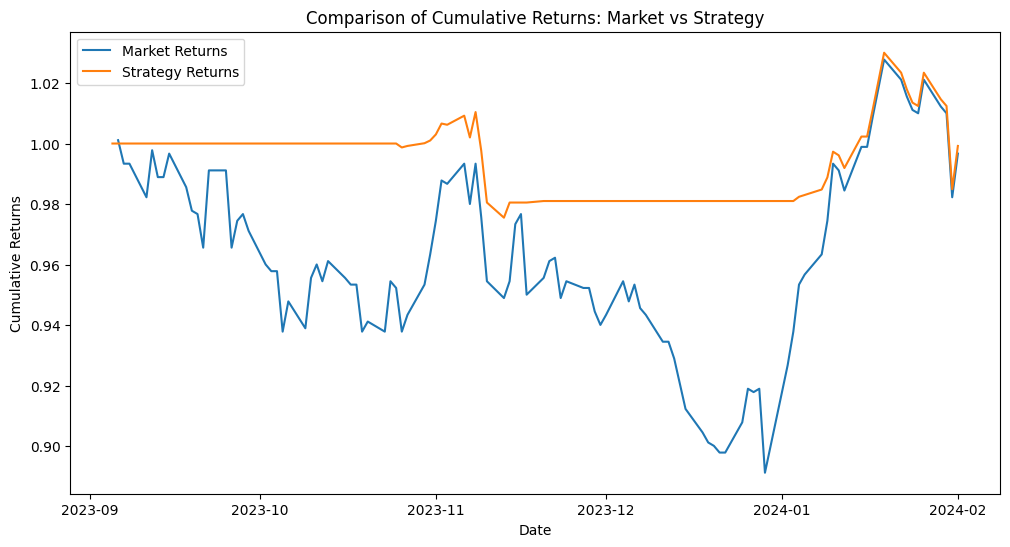

In [ ]:
import sys
sys.path.append("../Common")
# from CommonBacktest import CommonBacktest
import CommonBacktest
# initial_capital, shares_per_signal

backtest = CommonBacktest.CommonBacktest.backtest(data, 100000000, 100)
backtest.to_csv('data_out_backtest.csv')